In [1]:
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Dropout, MaxPool2D, Flatten
import matplotlib.pyplot as plt
import os

# Fix: remove/avoid kerastuner imports which crash under this environment due to protobuf incompatibility.
# (Not used anywhere in the core training/inference pipeline below.)

# Reproducibility (score-neutral / stability)
np.random.seed(42)
tf.random.set_seed(42)

# Paths (keep Kaggle-style relative paths used in the original notebook)
BASE_DIR = "../input/cassava-leaf-disease-classification"
TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
SAMPLE_SUB = os.path.join(BASE_DIR, "sample_submission.csv")
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train_images")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")

epochs = 10



2026-01-11 01:36:29.426974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768095389.440806      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768095389.445060      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-11 01:36:29.463104: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

(600, 800, 3)


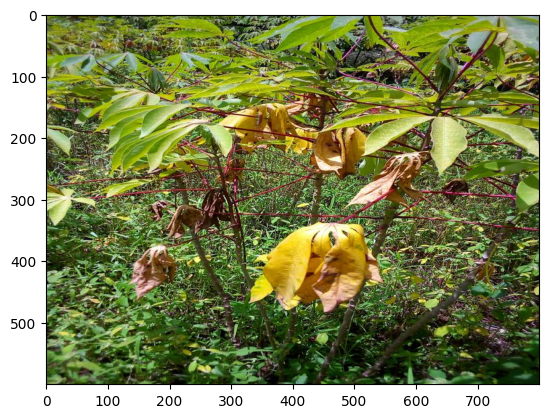

In [2]:
# Optional quick sanity check image display (non-blocking)
for f in os.listdir(TRAIN_IMG_DIR)[1000:1001]:
    img = cv2.imread(os.path.join(TRAIN_IMG_DIR, f))
    if img is not None:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        print(img.shape)
        plt.show()




In [3]:
def create_df(
    training_images=100, image_directory=TRAIN_IMG_DIR, test_dir=TEST_IMG_DIR
):
    """
    Returns:
      train_df with columns: x_col (filepath), y_col (label as string)
      test_df with columns: x (filepath), y (None)
    Fix: ensure correct label-image mapping by merging on image_id, not by zipping arbitrary directory order.
    """
    train = pd.read_csv(TRAIN_CSV)

    # Select a subset deterministically from train.csv order (keeps core intent of "training_images")
    train_small = train.iloc[:training_images].copy()
    train_small["x_col"] = train_small["image_id"].apply(
        lambda x: os.path.join(image_directory, x)
    )

    # Keras flow_from_dataframe expects labels as strings for categorical mode
    train_small["y_col"] = train_small["label"].astype(str)
    train_df = train_small[["x_col", "y_col"]].reset_index(drop=True)

    # Build test dataframe; we'll later align to sample_submission order to guarantee correct length/order.
    test_files = [os.path.join(test_dir, fi) for fi in os.listdir(test_dir)]
    test_df = pd.DataFrame({"x": test_files})
    test_df["y"] = None

    return train_df, test_df


def hyper_model():
    """
    Kept for compatibility with original notebook, though not used.
    """
    model = tf.keras.applications.ResNet50V2(
        include_top=False, classes=5, input_shape=(128, 128, 3)
    )
    for layers in model.layers[:]:
        layers.trainable = False

    flat = tf.keras.layers.Flatten()(model.output)
    out2 = Dense(5, activation="softmax")(flat)
    f_mod = tf.keras.Model(inputs=model.input, outputs=out2)
    f_mod.compile(
        loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
    )
    return f_mod


def model1():
    model = Sequential()
    model.add(
        Conv2D(
            64,
            kernel_size=3,
            activation="relu",
            input_shape=(128, 128, 3),
            padding="same",
        )
    )
    model.add(Conv2D(128, kernel_size=3, activation="relu", padding="same"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
    model.add(Conv2D(256, kernel_size=3, activation="relu", padding="same"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
    model.add(Conv2D(512, kernel_size=3, activation="relu", padding="same"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(3, 3)))
    model.add(Conv2D(1024, kernel_size=3, activation="relu", padding="same"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(3, 3)))
    model.add(Flatten())
    model.add(Dense(units=512, activation="relu"))
    model.add(Dense(units=128, activation="relu"))
    model.add(Dense(units=5, activation="softmax"))
    model.compile(
        optimizer="Adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


def test_pre_process(
    dataframe, test_df, image_size=128, batch_size=64, valid_split=0.15
):
    """
    Data preprocessing using ImageDataGenerator.
    """
    im_dg = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1.0 / 255, validation_split=valid_split
    )
    te_dg = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255)

    train = im_dg.flow_from_dataframe(
        dataframe,
        x_col="x_col",
        y_col="y_col",
        class_mode="categorical",
        batch_size=batch_size,
        target_size=(image_size, image_size),
        subset="training",
        shuffle=True,
        seed=42,
    )

    valid = im_dg.flow_from_dataframe(
        dataframe,
        x_col="x_col",
        y_col="y_col",
        class_mode="categorical",
        batch_size=batch_size,
        target_size=(image_size, image_size),
        subset="validation",
        shuffle=False,
        seed=42,
    )

    test = te_dg.flow_from_dataframe(
        test_df,
        x_col="x",
        y_col=None,
        batch_size=batch_size,
        target_size=(image_size, image_size),
        class_mode=None,
        shuffle=False,
    )

    return train, valid, test




In [4]:
model = model1()
model.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-11 01:36:36.264688: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768095396.265133      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:45:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 1024)   │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,726,021 (56.18 MB)

 Trainable params: 14,726,021 (56.18 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
train_df, test_df = create_df(training_images=90)
print("Train rows:", len(train_df))
print("Test discovered files:", len(test_df))



Train rows: 90
Test discovered files: 2677


In [6]:
train, valid, test = test_pre_process(train_df, test_df=test_df)



Found 77 validated image filenames belonging to 5 classes.
Found 13 validated image filenames belonging to 5 classes.
Found 2676 validated image filenames.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="x". These filename(s) will be ignored.
  warnings.warn(


In [7]:
ear_sto = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
history = model.fit(
    x=train,
    epochs=epochs,
    verbose=2,
    callbacks=[ear_sto],
    validation_data=valid,
    shuffle=True,
)



Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1768095398.532716      70 service.cc:148] XLA service 0x7f30c4011e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768095398.532756      70 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-11 01:36:38.562658: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768095398.741216      70 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768095403.036432      70 device_compiler.h:188] Compile

2/2 - 17s - 9s/step - accuracy: 0.6104 - loss: 3.1901 - val_accuracy: 0.0769 - val_loss: 1.6141
Epoch 2/10
2/2 - 0s - 155ms/step - accuracy: 0.2078 - loss: 1.6126 - val_accuracy: 0.4615 - val_loss: 1.5920
Epoch 3/10
2/2 - 0s - 167ms/step - accuracy: 0.6104 - loss: 1.5801 - val_accuracy: 0.4615 - val_loss: 1.5143
Epoch 4/10
2/2 - 0s - 159ms/step - accuracy: 0.6104 - loss: 1.4674 - val_accuracy: 0.4615 - val_loss: 1.4147
Epoch 5/10
2/2 - 0s - 159ms/step - accuracy: 0.6104 - loss: 1.1825 - val_accuracy: 0.4615 - val_loss: 1.4541
Epoch 6/10
2/2 - 0s - 134ms/step - accuracy: 0.6104 - loss: 1.1696 - val_accuracy: 0.4615 - val_loss: 1.4574
Epoch 7/10
2/2 - 0s - 143ms/step - accuracy: 0.6104 - loss: 1.2126 - val_accuracy: 0.4615 - val_loss: 1.4871


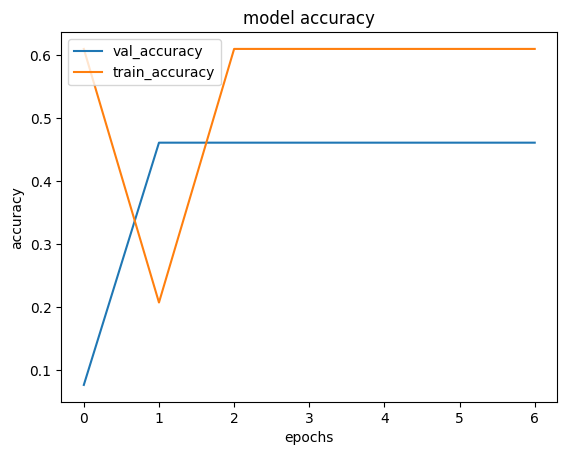

In [8]:
plt.plot(history.history.get("val_accuracy", []))
plt.plot(history.history.get("accuracy", []))
plt.title("model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend(["val_accuracy", "train_accuracy"], loc="upper left")
plt.show()



In [9]:
pred = model.predict(x=test, verbose=0)
label = np.argmax(pred, axis=1).astype(int)

# Fix: build submission in exact sample_submission order to avoid off-by-one / ordering issues.
sample_sub = pd.read_csv(SAMPLE_SUB)

# test generator preserves order; pull filenames from it (same length as `label`)
# filenames are relative paths like ".../test_images/xxxx.jpg" depending on Keras version
test_filenames = [os.path.basename(f) for f in test.filenames]

pred_df = pd.DataFrame({"image_id": test_filenames, "label": label})

# Align to sample_submission image_id order, and ensure row count matches exactly.
final_df = sample_sub[["image_id"]].merge(pred_df, on="image_id", how="left")

# Safety: if any missing predictions (shouldn't), fill with 0
final_df["label"] = final_df["label"].fillna(0).astype(int)

print("Submission rows:", len(final_df))
print(final_df.head())



Submission rows: 2676
         image_id  label
0  1234294272.jpg      3
1  1234332763.jpg      3
2  1234375577.jpg      3
3  1234555380.jpg      3
4  1234571117.jpg      3


In [10]:
# Write valid submission with required columns and .csv suffix
final_df.to_csv("submission.csv", index=False)
print("Wrote submission.csv")

Wrote submission.csv
